# D6 stage D: a bounded amplitude and a hidden parameter band

Why: a locally converged inner solution can still fail source and exit conditions.
What: construct an analytic amplitude envelope, then test the leading inner
conditions at declared points. How: logarithmic amplitudes, multiprecision
coordinates, targeted grids, and separate refinement checks.

The bound is analytic on an explicit complex rectangle. The inner results
are pointwise numerical evidence; this notebook does not certify a uniform
remainder or build the joined/corrected full PDE field.

In [1]:
from pathlib import Path
import csv
import mpmath as mp
from IPython.display import Image, display
from nscomp.d6d import generate, load_parameters, make_data, STUDY, WRITING
from nscomp.axis_bounds import feature_scales, exit_diagnostics
from nscomp.inner import inner_series
from nscomp.pressure import Schedule, pressure_trace

p = load_parameters()
summary = generate()
{key: summary[key] for key in (
    "complex_half_width", "pressure_width_decimal",
    "all_sampled_exit_checks_pass", "min_exit_lower",
    "uniform_inner_remainder_or_between_sample_bound")}

{'complex_half_width': 1.4705882352941177e-06,
 'pressure_width_decimal': '1.964113107374275489647484631442375390393770622465e-26',
 'all_sampled_exit_checks_pass': True,
 'min_exit_lower': 3.0,
 'uniform_inner_remainder_or_between_sample_bound': False}

## Keep the amplitude in logarithmic form

The exact rational estimate bounds the primitive over a rectangle, then chooses
log(C) above Lambda times that bound. Numerical pole locations are used only
for the figure and primitive evaluation. They are not the certificate.
The very conservative C cannot be represented as an ordinary float.

Upward-rounded log(C): 125161626185397341987831466081741490731703644.3950742926928556889883981274170567881132
H_star zero: -0.0044444346906930751843186059511041719475472548415660247834175036197931833269759073
Fine-band width: 1.964113107374275489647484631442375390393770622465e-26
Distinct binary64 coordinates: 1 out of 19


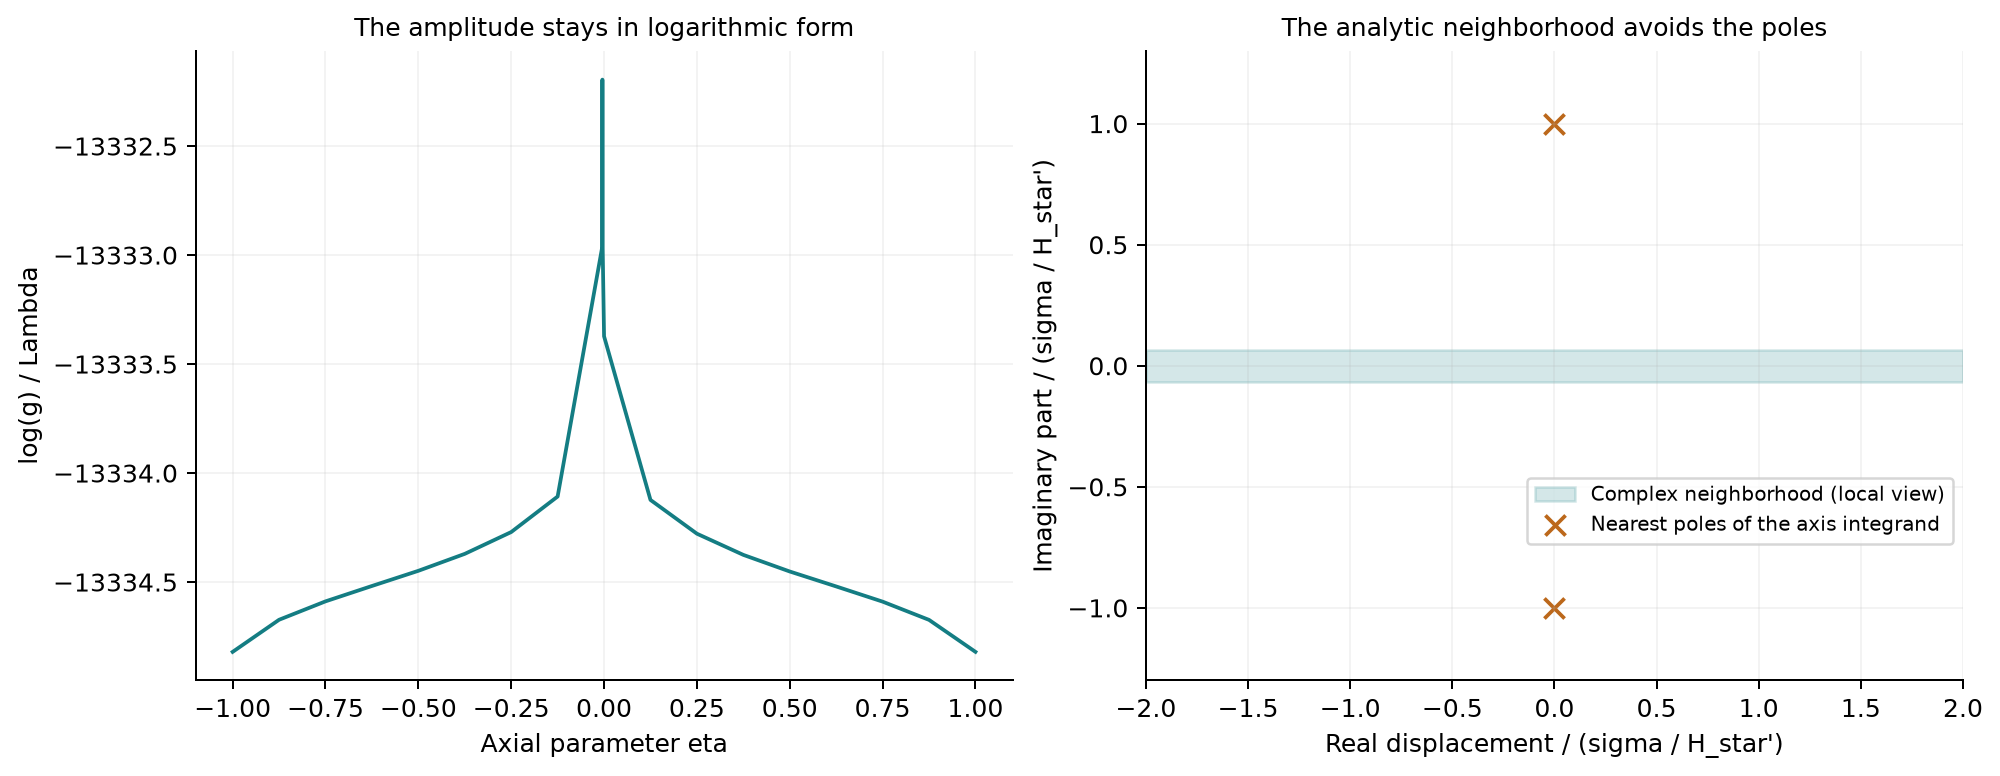

In [2]:
print("Upward-rounded log(C):", summary["log_C_upper"])
print("H_star zero:", summary["H_zero_decimal"])
print("Fine-band width:", summary["pressure_width_decimal"])
print("Distinct binary64 coordinates:",
      summary["binary64_distinct_critical_coordinates"],
      "out of", summary["critical_coordinate_count"])
display(Image(filename=str(WRITING / "figures/01_logarithmic_amplitude_bound.png")))

## A targeted scan finds a failure a coarse grid can miss

Each scale choice uses eta = eta_H + c Delta_eta with its own Delta_eta.
The smaller Lambda fails angular positivity close to the zero of H_star.
The coordinate strings below preserve distinctions erased by binary64.

Lambda/P_star^2 = 1e+16 minimum sampled Lambda*p1 = -651784.5798193823 at scaled displacement 0.6666666666666666
eta = -0.0044444346906930738749098677015873097900979921650150743532125181348106642732508655
Lambda/P_star^2 = 1e+24 minimum sampled Lambda*p1 = 5.993304314816193 at scaled displacement 0.6666666666666666
eta = -0.0044444346906930751843185928570167894523786332670733980179079993177433284771507168


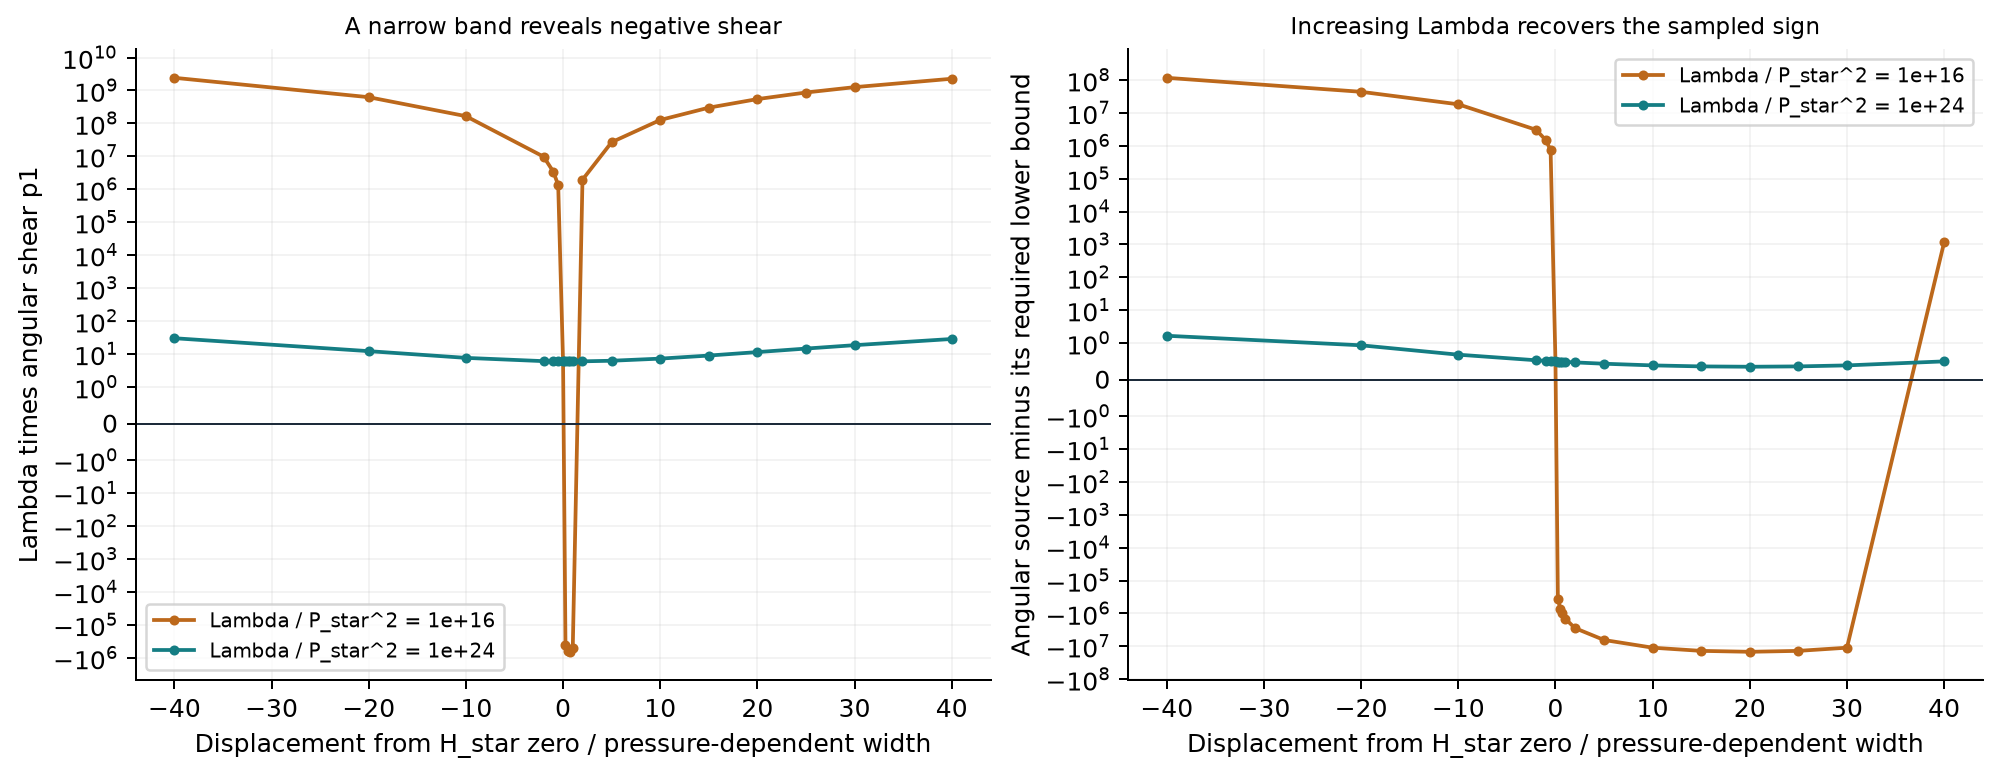

In [3]:
def rows(name):
    with (STUDY / "data" / name).open(encoding="utf-8", newline="") as stream:
        return list(csv.DictReader(stream))

critical = rows("critical_scale_scan.csv")
for ratio in (p["comparison_Lambda_over_P_squared"], p["Lambda_over_P_squared"]):
    selected = [r for r in critical if float(r["Lambda_over_P_squared"]) == ratio]
    worst = min(selected, key=lambda r: float(r["scaled_p1"]))
    print("Lambda/P_star^2 =", ratio,
          "minimum sampled Lambda*p1 =", worst["scaled_p1"],
          "at scaled displacement", worst["scaled_offset"])
    print("eta =", worst["eta_decimal"])
display(Image(filename=str(WRITING / "figures/02_hidden_parameter_band.png")))

## An exit lower bound without overflow

For positive p1, retain p1 alone when chi > 0.99 and use
p1 + min(p2^2/p1, 3) otherwise. Both are lower bounds on the exit expression.
Passing 2.2 with the lower bound is sufficient at that point. The radial-degree
plot is a separate consistency check; it does not turn the sample grid into a
uniform certificate.

Exit coordinates checked: 51
Minimum reported exit lower bound: 3.0
Minimum sampled source margin over all Y: 0.3459254410184261
Minimum sampled Phi: 0.27111405681342626


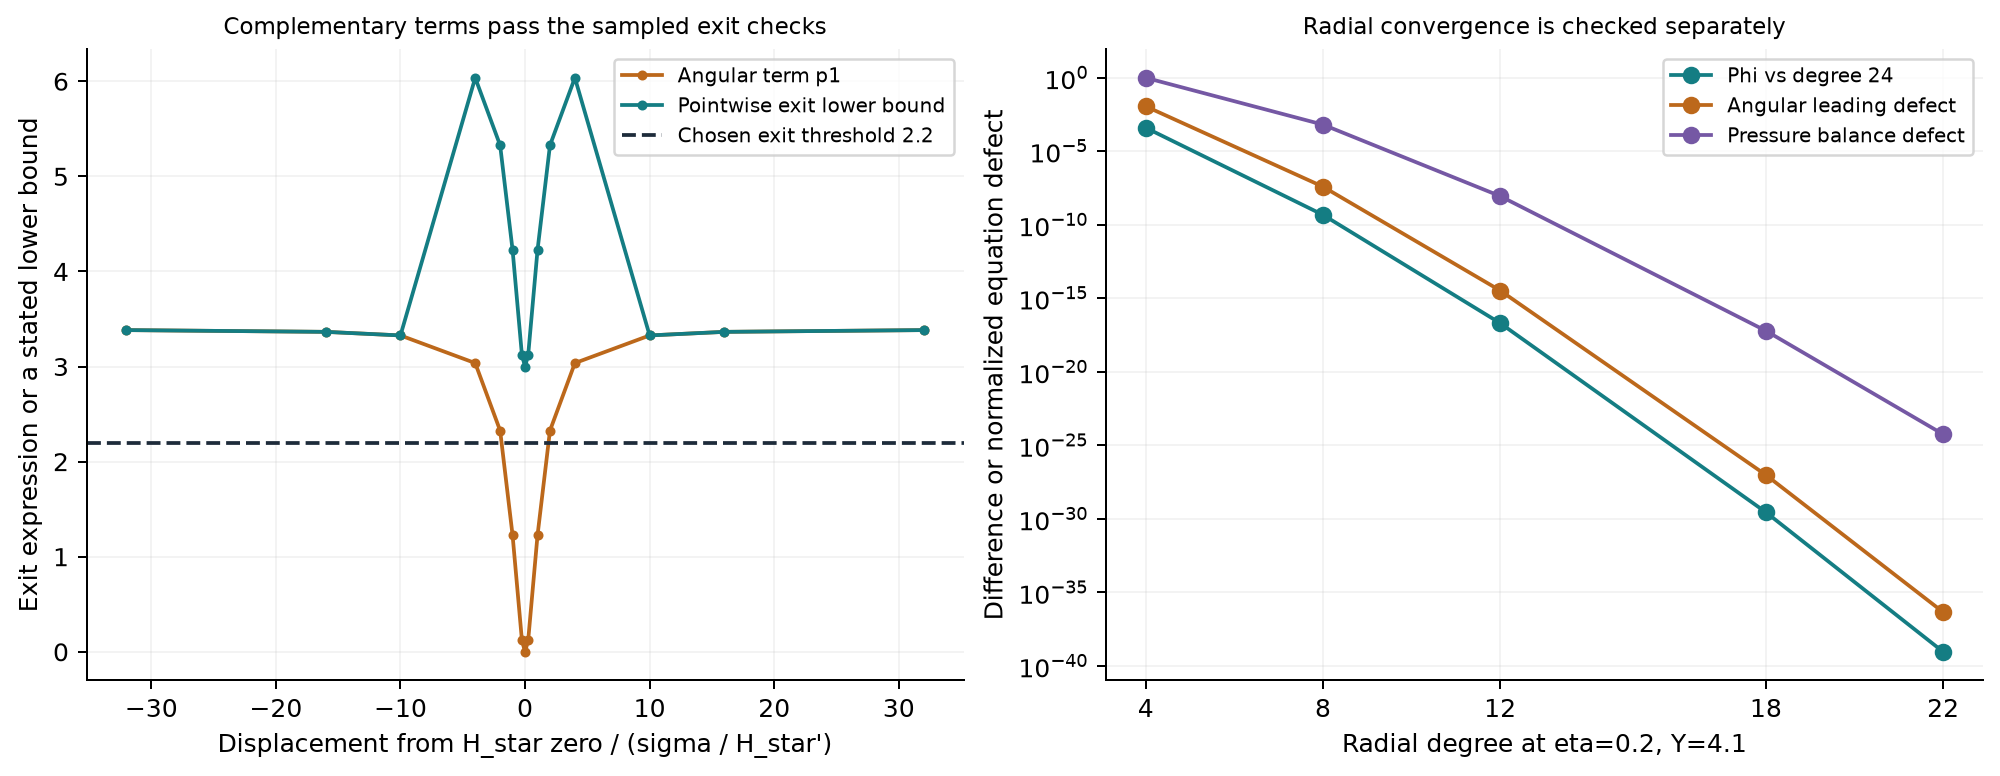

In [4]:
exit_rows = rows("exit_checks.csv")
print("Exit coordinates checked:", len(exit_rows))
print("Minimum reported exit lower bound:", summary["min_exit_lower"])
print("Minimum sampled source margin over all Y:", summary["min_sampled_Sq_margin"])
print("Minimum sampled Phi:", summary["min_sampled_Phi"])
display(Image(filename=str(WRITING / "figures/03_sampled_exit_and_convergence.png")))

## Separate precision, radial degree, and pressure input

The failure and a passing point are reevaluated at degrees 12/18 and 65/90
decimal digits. The pressure input is separately refined from 128 to 256
quadrature nodes. Small local equation defects do not imply equally accurate
absolute pressure data or a small full Navier–Stokes residual.

In [5]:
for table in ("precision_checks.csv", "pressure_sensitivity.csv", "degree_convergence.csv"):
    print(table)
    for row in rows(table):
        print(row)

precision_checks.csv
{'Lambda_over_P_squared': '1e+16', 'scaled_offset': '0.5', 'low_degree': '12', 'high_degree': '18', 'low_digits': '65', 'high_digits': '90', 'scaled_p1_low': '-611052.4968396937', 'scaled_p1_high': '-611052.4968396937', 'scaled_p1_relative_change': '7.701529618224443e-51', 'Sq_margin_absolute_change': '1.376597259225361e-44'}
{'Lambda_over_P_squared': '1e+24', 'scaled_offset': '20', 'low_degree': '12', 'high_degree': '18', 'low_digits': '65', 'high_digits': '90', 'scaled_p1_low': '11.47508712030517', 'scaled_p1_high': '11.47508712030517', 'scaled_p1_relative_change': '9.018339894869434e-44', 'Sq_margin_absolute_change': '5.286626363171304e-49'}
pressure_sensitivity.csv
{'quantity': 'scaled_p1', 'baseline': '11.47508712030517', 'reference': '11.47508712030517', 'absolute_change': '1.0046888878391193e-16'}
{'quantity': 'Sq_margin', 'baseline': '0.3532582298868312', 'reference': '0.35325822988683114', 'absolute_change': '7.535166658793098e-17'}
degree_convergence.csv


## Explore one point without changing the published baseline

Change the arguments of the helper below for a local experiment. It recomputes
the amplitude bound for the chosen Lambda. It does not modify parameters,
baseline CSVs, or figures. Preserve multiprecision coordinates throughout.

In [6]:
def inspect_point(ratio=1e16, scaled_offset="0.5", degree=12, digits=80):
    trace = pressure_trace(Schedule(**p["pressure_schedule"]),
                           p["pressure_quadrature_order"])
    datum, _ = make_data(p, trace, ratio)
    with mp.workdps(p["coordinate_digits"]):
        scales = feature_scales(datum, trace, p["coordinate_digits"])
        eta = scales["center"] + mp.mpf(scaled_offset) * scales["pressure_width"]
        series = inner_series(datum, eta, degree, digits, axis_pressure=trace)
        result = exit_diagnostics(series, p["exit_Y"])
        return {"eta": mp.nstr(eta, 80),
                "Lambda*p1": mp.nstr(result["scaled_p1"], 18),
                "source_margin": mp.nstr(result["Sq_margin"], 18),
                "positive_angular_shear": bool(result["p1"] > 0)}

inspect_point()

{'eta': '-0.0044444346906930742022620522639664271238049391203783295865321923872867743481510027',
 'Lambda*p1': '-611052.496839693723',
 'source_margin': '-724112.219784595675',
 'positive_angular_shear': False}

The next mathematical dependency is uniform control of the inner approximation
and its exit conditions, followed by the outer schedule/moment/stress checks,
annular joining, and first correction. See the matching article, source notes,
and D6 implementation ledger. This is background-profile work before the
paper's later oscillatory stress-cancellation stage.